# CISC839 — Assignment 2
## Part 3: Survival Analysis of Pull Request Lifecycle — Human vs. AI Agents

---
**Name:** Mahmoud Alyosify | **ID:** 20595453  
**Course:** CISC 839 Topics in Information Systems W26

---

### Research Question
> *Do AI-authored pull requests get merged or closed **faster** than human-authored ones — and what factors drive time-to-resolution?*

### Survival Analysis Framework
| Component | Definition |
|-----------|------------|
| **Subject** | Each GitHub Pull Request (PR) |
| **Event** | PR resolved: either merged (`merged_at` ≠ null) or closed without merge (`closed_at` ≠ null, `merged_at` = null) |
| **Time (T)** | Hours from `created_at` → `min(merged_at, closed_at)` |
| **Censored** | PRs still open at observation end — event not yet observed |
| **Groups** | `is_agentic = 1` (AI agent) vs. `is_agentic = 0` (human developer) |


---
## Block 0 — Imports & Configuration

In [1]:
import re, warnings, sys
from pathlib import Path

warnings.filterwarnings("ignore")

!pip install lifelines
import numpy as np
import pandas as pd
from scipy import stats

# Survival Analysis — lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

matplotlib.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("Set2")

# ── Global constants (same as Part 2)
STAR_THRESHOLD  = 100
TTR_CAP_HOURS   = 365 * 24
OBSERVATION_END = pd.Timestamp("2025-01-01", tz="UTC")

PALETTE = {"AI Agent": "#e07b54", "Human": "#5b8db8"}

print("✓ All libraries imported successfully")
print(f"  lifelines version: ", end="")
import lifelines; print(lifelines.__version__)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f35e68aa852e994db1f57cedb644759347ce1baf02b9c3be9dd0e0824ec1125a
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✓ All libraries imported successfully
  lifelines version: 0.30.3


---
## Block 1 — Load AIDev Tables

I load six Parquet tables from the **AIDev** dataset hosted on Hugging Face.  
This replicates the exact same loading strategy used in Part 2 for consistency.

| Table | Description |
|-------|-------------|
| `agentic_pull_requests` | PRs authored by AI coding agents (e.g., Devin, GitHub Copilot Workspace) |
| `human_pull_requests` | PRs authored by human developers |
| `repositories` | Repo metadata (stars, language, contributors) |
| `pr_reviews` | Review comments and reviewer metadata |
| `pr_commit_details` | Per-commit line additions/deletions and file paths |
| `human_pr_task_type` | Pre-labeled task categories for human PRs |

In [2]:
def load_data_hf() -> dict:
    print("━" * 65)
    print("BLOCK 1 ▸ Loading AIDev tables from Hugging Face")
    print("━" * 65)
    base = "hf://datasets/hao-li/AIDev"
    files = {
        "agentic_pull_requests": "pull_request.parquet",
        "human_pull_requests":   "human_pull_request.parquet",
        "human_pr_task_type":    "human_pr_task_type.parquet",
        "repositories":          "repository.parquet",
        "pr_reviews":            "pr_reviews.parquet",
        "pr_commit_details":     "pr_commit_details.parquet",
    }
    tables = {}
    for name, file in files.items():
        path = f"{base}/{file}"
        try:
            df = pd.read_parquet(path)
            print(f"  ✓ {name:<50s} {len(df):>10,} rows × {df.shape[1]} cols")
            tables[name] = df
        except Exception as e:
            print(f"  ✗ {name:<50s} [ERROR: {e}]")
            tables[name] = None
    return tables

tables = load_data_hf()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 1 ▸ Loading AIDev tables from Hugging Face
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ agentic_pull_requests                                  33,596 rows × 14 cols
  ✓ human_pull_requests                                     6,618 rows × 13 cols
  ✓ human_pr_task_type                                      6,618 rows × 6 cols
  ✓ repositories                                            2,807 rows × 7 cols
  ✓ pr_reviews                                             28,875 rows × 7 cols
  ✓ pr_commit_details                                     711,923 rows × 14 cols


---
## Block 2 — Survival Time & Censoring Engineering

### 2.1 Event & Time Definition

**Event (`event_observed = 1`):** PR was closed or merged before the observation end date.  
**Censored (`event_observed = 0`):** PR is still open at the observation end — the event has not yet occurred.

**Survival time** = hours from `created_at` → `min(merged_at, closed_at)`.  
For censored PRs, survival time = hours from `created_at` → `OBSERVATION_END`.

### 2.2 Why Right-Censoring is Appropriate
Open PRs are **not missing data** — they are valid observations where I know the subject survived *at least* until the end of our study window. Ignoring them (as done in Part 2's OLS) would bias survival estimates upward (overestimate resolution speed). Cox regression and KM properly handle them via the partial-likelihood mechanism.

In [3]:
# ── Helper: Repo lookup & star filter (identical logic to Part 2)
def build_repo_lookup(repos: pd.DataFrame) -> pd.DataFrame:
    r = repos.copy()
    r["stars"]   = pd.to_numeric(r.get("stars", r.get("stargazers_count", 0)),
                                  errors="coerce").fillna(0)
    r["id_str"]  = r["id"].astype(str)
    r["url_str"] = r.get("html_url", r.get("url", "")).str.strip()
    r["lang"]    = r.get("language", "unknown").fillna("unknown")
    return r[["id_str", "url_str", "stars", "lang"]]

def get_repo_meta(df, repo_lkp, join_on="id"):
    if join_on == "id":
        key = df["repo_id"].astype(str)
        lkp = repo_lkp.set_index("id_str")
    else:
        key = df["repo_url"].str.strip()
        lkp = repo_lkp.set_index("url_str")
    stars = key.map(lkp["stars"]).fillna(0)
    lang  = key.map(lkp["lang"]).fillna("unknown")
    return pd.DataFrame({"repo_stars": stars.values,
                         "repo_lang":  lang.values})

# ── Churn aggregation
def build_pr_churn(pcd: pd.DataFrame) -> pd.DataFrame:
    p = pcd.copy()
    adds = pd.to_numeric(p["commit_stats_additions"], errors="coerce").fillna(0).clip(0)
    dels = pd.to_numeric(p["commit_stats_deletions"], errors="coerce").fillna(0).clip(0)
    p["churn"] = adds + dels
    # Count unique filenames per PR
    has_fn = "filename" in p.columns
    agg = p.groupby("pr_id").agg(
        total_churn=("churn", "sum"),
        n_commits=("pr_id", "count"),
    )
    if has_fn:
        agg["n_files"] = p.groupby("pr_id")["filename"].nunique()
    else:
        agg["n_files"] = np.nan
    return agg

# ── Review diversity (CDI)
def compute_cdi(pr_reviews: pd.DataFrame) -> pd.Series:
    grp = pr_reviews.groupby("pr_id")["user"]
    return (grp.nunique() / grp.count()).clip(0, 1).rename("cdi")

# ── Task type from PR title
TASK_MAP = {
    "feat": "feature", "feature": "feature",
    "fix": "fix", "bug": "fix",
    "refactor": "refactor", "perf": "refactor",
    "docs": "docs", "doc": "docs",
    "test": "test", "chore": "chore", "ci": "chore",
}
PREFIX_RE = re.compile(r"^([a-z]+)[:(\s]", re.IGNORECASE)

def infer_task_type(titles: pd.Series) -> pd.Series:
    def _t(s):
        m = PREFIX_RE.match(str(s))
        return TASK_MAP.get(m.group(1).lower(), "other") if m else "other"
    return titles.map(_t)

def task_type_from_table(pr_ids, task_table):
    # human_pr_task_type uses "id" column (same as PR id)
    id_col = "id" if "id" in task_table.columns else "pr_id"
    type_col = "type" if "type" in task_table.columns else "task_type"
    lkp = task_table.set_index(id_col)[type_col] if task_table is not None else pd.Series(dtype=str)
    return pr_ids.map(lkp).fillna("other")

# ── Body features
def body_features(body_col: pd.Series) -> pd.DataFrame:
    body = body_col.fillna("")
    wc   = body.str.split().str.len().fillna(0).astype(int)
    return pd.DataFrame({
        "log_body_length": np.log1p(wc),
        "is_silent":       (body.str.strip().str.len() == 0).astype(int),
    })

print("✓ Helper functions defined")

✓ Helper functions defined


In [4]:
def compute_survival_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute survival time and event indicator for each PR.

    Returns a DataFrame with:
      - duration_hours : survival time (hours until event or censoring)
      - event_observed : 1 = event occurred, 0 = censored (still open)
      - merged         : 1 = PR was specifically merged (subset of events)

    CENSORING DESIGN:
      - If merged_at or closed_at exists → event_observed = 1
        → duration = hours from created_at to min(merged_at, closed_at)
      - If still open → event_observed = 0
        → duration = hours from created_at to OBSERVATION_END
        → This is RIGHT censoring — I know the PR survived AT LEAST this long
    """
    created = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
    merged  = pd.to_datetime(df["merged_at"],  utc=True, errors="coerce")
    closed  = pd.to_datetime(df["closed_at"],  utc=True, errors="coerce")

    resolved = merged.combine_first(closed)

    event_observed = resolved.notna().astype(int)

    end_time = resolved.where(resolved.notna(), OBSERVATION_END)
    duration = (end_time - created).dt.total_seconds() / 3600.0

    invalid = (duration <= 0) | duration.isna()
    duration[invalid]       = np.nan
    event_observed[invalid] = np.nan
    duration = duration.clip(upper=TTR_CAP_HOURS)

    return pd.DataFrame({
        "duration_hours": duration.values,
        "event_observed": event_observed.values,
        "merged":         merged.notna().astype(int).values,
    })

print("✓ Survival time function defined")

✓ Survival time function defined


In [5]:
def build_survival_dataset(tables: dict) -> pd.DataFrame:
    print("━" * 65)
    print("BLOCK 2 ▸ Building Survival Analysis Dataset")
    print("━" * 65)

    repos  = tables["repositories"]
    ag     = tables["agentic_pull_requests"]
    hu     = tables["human_pull_requests"]
    rev    = tables["pr_reviews"]
    pcd    = tables["pr_commit_details"]
    hu_tasks = tables.get("human_pr_task_type")
    repo_lkp  = build_repo_lookup(repos)
    valid_ids  = set(repo_lkp.loc[repo_lkp["stars"] >= STAR_THRESHOLD, "id_str"])
    valid_urls = set(repo_lkp.loc[repo_lkp["stars"] >= STAR_THRESHOLD, "url_str"])
    print(f"  Repos ≥{STAR_THRESHOLD} stars: {len(valid_ids):,}")

    ag = ag[ag["repo_id"].astype(str).isin(valid_ids)].copy()
    hu = hu[hu["repo_url"].str.strip().isin(valid_urls)].copy()
    print(f"  Agentic after star filter: {len(ag):,}")
    print(f"  Human   after star filter: {len(hu):,}")
    pr_churn = build_pr_churn(pcd)
    cdi      = compute_cdi(rev)
    print(f"  Churn aggregated for {len(pr_churn):,} PRs")
    review_count = rev.groupby("pr_id").size().rename("n_reviews")

    def _half(df: pd.DataFrame, flag: int, join_on: str, task_table=None) -> pd.DataFrame:
        out = pd.DataFrame()
        out["pr_id"]      = df["id"].values
        out["is_agentic"] = flag
        surv = compute_survival_time(df)
        out["duration_hours"] = surv["duration_hours"].values
        out["event_observed"] = surv["event_observed"].values
        out["merged"]         = surv["merged"].values
        repo_meta = get_repo_meta(df, repo_lkp, join_on=join_on)
        out["log_stars"] = np.log1p(
            pd.to_numeric(repo_meta["repo_stars"], errors="coerce").fillna(0)
        )
        out["repo_lang"] = repo_meta["repo_lang"].values
        bd = body_features(df["body"])
        out["log_body_length"] = bd["log_body_length"].values
        out["is_silent"]       = bd["is_silent"].values
        if task_table is not None:
            out["task_type"] = task_type_from_table(df["id"], task_table).values
        else:
            out["task_type"] = infer_task_type(df["title"]).values

        return out.reset_index(drop=True)

    global OBSERVATION_END
    all_dates = []
    for col in ["merged_at", "closed_at", "created_at"]:
        for tbl in [ag, hu]:
            if col in tbl.columns:
                d = pd.to_datetime(tbl[col], utc=True, errors="coerce").dropna()
                if len(d): all_dates.append(d.max())
    if all_dates:
        OBSERVATION_END = max(all_dates)
        print(f"  Observation end (censoring cutoff): {OBSERVATION_END.date()}")

    df_a = _half(ag, 1, "id")
    df_h = _half(hu, 0, "url", task_table=hu_tasks)
    df   = pd.concat([df_a, df_h], ignore_index=True)

    df = df.merge(pr_churn[["total_churn", "n_commits", "n_files"]],
                  left_on="pr_id", right_index=True, how="left")
    df = df.merge(cdi,          left_on="pr_id", right_index=True, how="left")
    df = df.merge(review_count, left_on="pr_id", right_index=True, how="left")

    df["log_churn"]   = np.log1p(pd.to_numeric(df["total_churn"], errors="coerce").fillna(0))
    df["log_files"]   = np.log1p(pd.to_numeric(df["n_files"],     errors="coerce").fillna(0))
    df["log_commits"] = np.log1p(pd.to_numeric(df["n_commits"],   errors="coerce").fillna(0))
    df["log_reviews"] = np.log1p(pd.to_numeric(df["n_reviews"],   errors="coerce").fillna(0))
    df["group"] = df["is_agentic"].map({1: "AI Agent", 0: "Human"})

    total = len(df)
    n_events = df["event_observed"].sum()
    n_cens   = (df["event_observed"] == 0).sum()
    print(f"\n  Total PRs          : {total:>10,}")
    print(f"  Events (resolved)  : {int(n_events):>10,} ({n_events/total*100:.1f}%)")
    print(f"  Censored (open)    : {int(n_cens):>10,}  ({n_cens/total*100:.1f}%)")
    print(f"  Agentic PRs        : {(df.is_agentic==1).sum():>10,}")
    print(f"  Human PRs          : {(df.is_agentic==0).sum():>10,}")
    return df

df_surv_raw = build_survival_dataset(tables)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 2 ▸ Building Survival Analysis Dataset
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Repos ≥100 stars: 2,807
  Agentic after star filter: 33,596
  Human   after star filter: 6,569
  Churn aggregated for 33,580 PRs
  Observation end (censoring cutoff): 2025-07-30

  Total PRs          :     40,165
  Events (resolved)  :     37,387 (93.1%)
  Censored (open)    :      2,778  (6.9%)
  Agentic PRs        :     33,596
  Human PRs          :      6,569


---
## Block 3 — Preprocessing for Survival Analysis

**Key difference from Part 2:**  
- I **keep** open PRs (censored = 0) — they carry valid right-censored survival information.  
- I only drop rows with invalid (negative/zero/null) duration.
- I do **not** log-transform the survival time — Cox regression operates on raw time internally.

In [6]:
def preprocess_survival(df: pd.DataFrame) -> pd.DataFrame:
    print("━" * 65)
    print("BLOCK 3 ▸ Survival Dataset Preprocessing")
    print("━" * 65)
    print(f"  Input rows         : {len(df):>10,}")

    df = df.dropna(subset=["duration_hours", "event_observed"]).copy()
    df = df[df["duration_hours"] > 0].copy()
    print(f"  After validity drop: {len(df):>10,}")

    # Duration in days (more interpretable for plots)
    df["duration_days"] = df["duration_hours"] / 24.0

    # Task type dummies (reference = 'other')
    td = pd.get_dummies(df["task_type"], prefix="task")
    td.drop(columns=["task_other"], errors="ignore", inplace=True)
    df = pd.concat([df, td], axis=1)

    # Language dummies (top-8)
    top8 = df["repo_lang"].value_counts().head(8).index.tolist()
    df["repo_lang_grp"] = df["repo_lang"].where(df["repo_lang"].isin(top8), "other_lang")
    ld = pd.get_dummies(df["repo_lang_grp"], prefix="lang", drop_first=True)
    ld.drop(columns=[c for c in ld.columns if "unknown" in c.lower()], errors="ignore", inplace=True)
    df = pd.concat([df, ld], axis=1)

    # Impute missing numeric covariates with column median
    num_cols = ["log_churn", "log_files", "log_commits", "log_reviews",
                "log_stars", "log_body_length", "is_silent", "cdi"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())

    # Convert event to int
    df["event_observed"] = df["event_observed"].astype(int)

    ag_n  = (df.is_agentic == 1).sum()
    hu_n  = (df.is_agentic == 0).sum()
    ev_ag = df[df.is_agentic == 1]["event_observed"].sum()
    ev_hu = df[df.is_agentic == 0]["event_observed"].sum()
    print(f"  Agentic PRs        : {ag_n:>10,}  (events: {int(ev_ag):,})")
    print(f"  Human PRs          : {hu_n:>10,}  (events: {int(ev_hu):,})")
    print(f"  Censoring rate     : {(df.event_observed==0).mean()*100:.1f}%")
    print(f"  Median duration    : {df.duration_days.median():.1f} days")

    return df

df = preprocess_survival(df_surv_raw)
df.head(3)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 3 ▸ Survival Dataset Preprocessing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input rows         :     40,165
  After validity drop:     40,165
  Agentic PRs        :     33,596  (events: 31,284)
  Human PRs          :      6,569  (events: 6,103)
  Censoring rate     : 6.9%
  Median duration    : 0.0 days


,pr_id,is_agentic,duration_hours,event_observed,merged,log_stars,repo_lang,log_body_length,is_silent,task_type,...,task_test,repo_lang_grp,lang_Go,lang_HTML,lang_Java,lang_JavaScript,lang_Python,lang_Rust,lang_TypeScript,lang_other_lang
0,3264933329,1,76.038611,1,0,7.115582,Python,5.549076,0,fix,...,False,Python,False,False,False,False,True,False,False,False
1,3265118634,1,17.258056,1,1,5.971262,TypeScript,3.912023,0,other,...,False,TypeScript,False,False,False,False,False,False,True,False
2,3265640341,1,0.100833,1,1,6.226537,Swift,6.318968,0,other,...,False,other_lang,False,False,False,False,False,False,False,True


---
## Block 4 — Descriptive Statistics

Examine duration distributions before fitting survival models.

In [7]:
print("━" * 65)
print("BLOCK 4 ▸ Descriptive Statistics")
print("━" * 65)

for group, label in [(1, "AI Agent"), (0, "Human")]:
    sub = df[df.is_agentic == group]
    d   = sub["duration_days"]
    ev  = sub["event_observed"]
    print(f"\n  [{label}]")
    print(f"    N              : {len(sub):>8,}")
    print(f"    Events (%)     : {ev.sum():>8,}  ({ev.mean()*100:.1f}%)")
    print(f"    Median dur     : {d.median():>8.1f} days")
    print(f"    Mean dur       : {d.mean():>8.1f} days")
    print(f"    IQR            : [{d.quantile(.25):.1f}, {d.quantile(.75):.1f}] days")
    print(f"    Max dur        : {d.max():>8.1f} days")

print("\n  Overall censoring rate:", f"{(df.event_observed==0).mean()*100:.1f}%")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 4 ▸ Descriptive Statistics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [AI Agent]
    N              :   33,596
    Events (%)     :   31,284  (93.1%)
    Median dur     :      0.0 days
    Mean dur       :      3.9 days
    IQR            : [0.0, 0.8] days
    Max dur        :    160.1 days

  [Human]
    N              :    6,569
    Events (%)     :    6,103  (92.9%)
    Median dur     :      0.3 days
    Mean dur       :      9.5 days
    IQR            : [0.0, 3.5] days
    Max dur        :    209.9 days

  Overall censoring rate: 6.9%


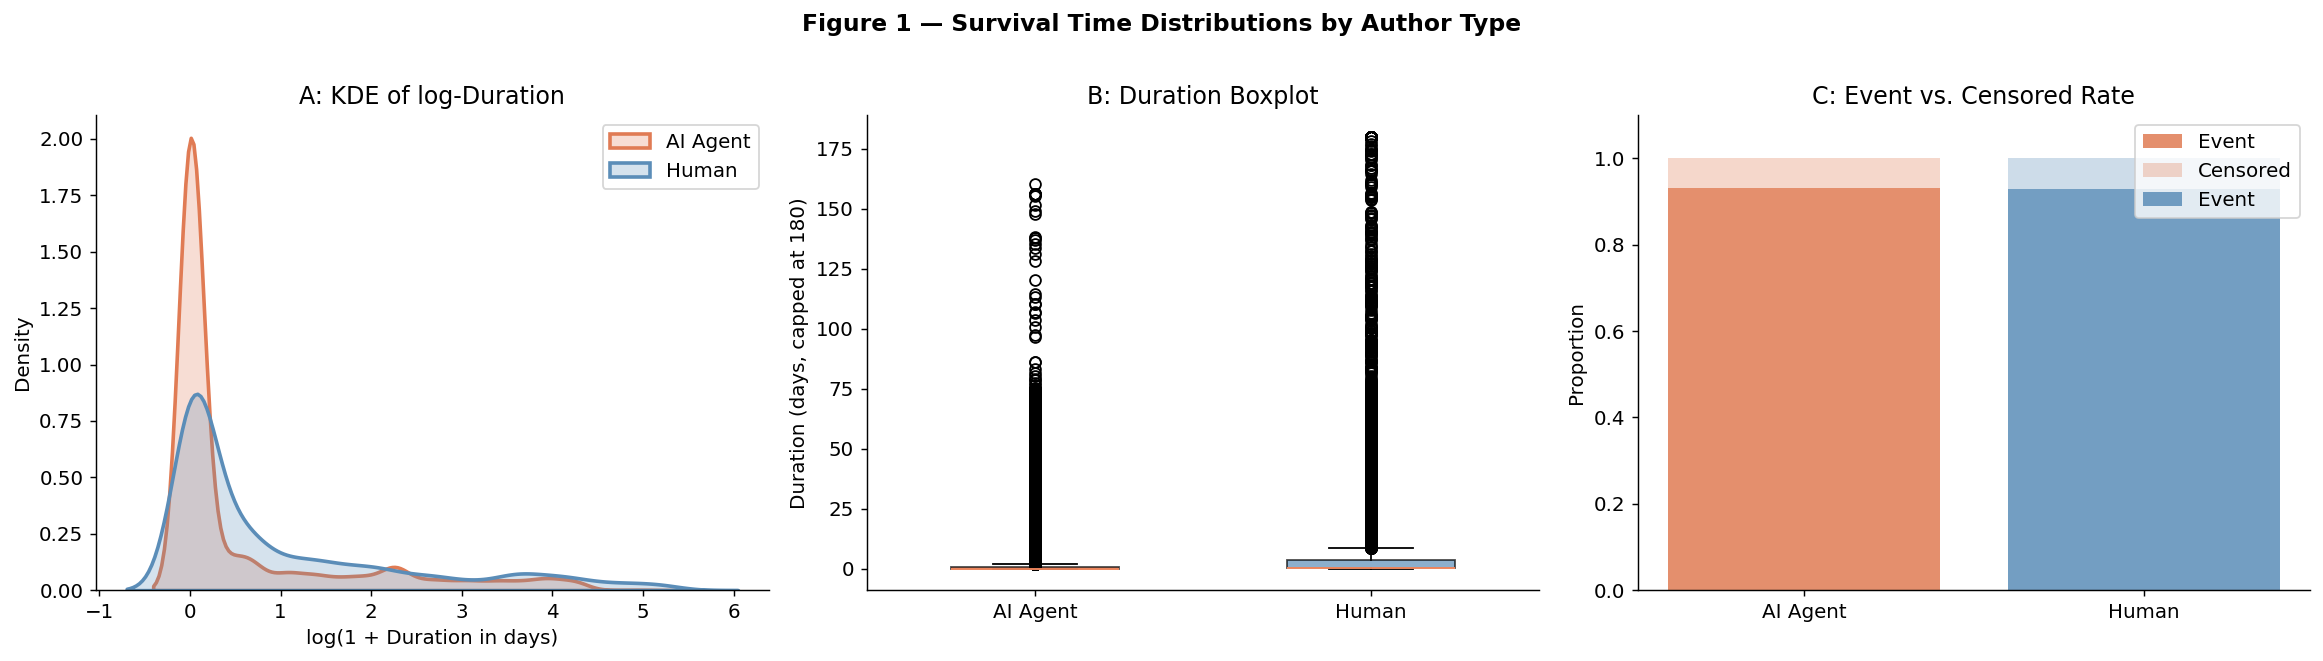

✓ Figure 1 saved


In [8]:
# ── Fig 1: Duration distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 1 — Survival Time Distributions by Author Type",
             fontsize=13, fontweight="bold", y=1.01)
ax = axes[0]
for group, label in [(1, "AI Agent"), (0, "Human")]:
    sub = df[df.is_agentic == group]["duration_days"].clip(upper=365)
    sns.kdeplot(np.log1p(sub), ax=ax, label=label,
                color=PALETTE[label], linewidth=2, fill=True, alpha=0.25)
ax.set_xlabel("log(1 + Duration in days)")
ax.set_ylabel("Density")
ax.set_title("A: KDE of log-Duration")
ax.legend()
ax = axes[1]
plot_data = [
    df[df.is_agentic == 1]["duration_days"].clip(upper=180).values,
    df[df.is_agentic == 0]["duration_days"].clip(upper=180).values,
]
bp = ax.boxplot(plot_data, patch_artist=True,
                labels=["AI Agent", "Human"], widths=0.5)
for patch, color in zip(bp["boxes"], list(PALETTE.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Duration (days, capped at 180)")
ax.set_title("B: Duration Boxplot")
ax = axes[2]
for i, (group, label) in enumerate([(1, "AI Agent"), (0, "Human")]):
    sub = df[df.is_agentic == group]["event_observed"]
    ev  = sub.mean()
    ax.bar(i, ev,     color=PALETTE[label], alpha=0.85, label="Event")
    ax.bar(i, 1 - ev, bottom=ev, color=PALETTE[label], alpha=0.3, label="Censored" if i==0 else "")
ax.set_xticks([0, 1])
ax.set_xticklabels(["AI Agent", "Human"])
ax.set_ylabel("Proportion")
ax.set_title("C: Event vs. Censored Rate")
ax.set_ylim(0, 1.1)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("fig1_duration_distributions.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 1 saved")

---
## Block 5 — Kaplan-Meier Estimator

### What is the Kaplan-Meier Estimator?
The **Kaplan-Meier (KM) estimator** is a non-parametric estimator of the survival function:

$$S(t) = P(T > t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

where $d_i$ = number of events at time $t_i$ and $n_i$ = number at risk just before $t_i$.

**Interpretation here:**  
$S(t)$ = probability that a PR is *still open* (not yet resolved) at time $t$.  
A lower survival curve at any $t$ means faster resolution.

**Assumptions:**  
- Censoring is **independent** of the event (non-informative censoring) — reasonable here since PRs are censored only due to observation cutoff, not because they are "difficult" to resolve.
- Survival probability is constant within each interval.

In [9]:
print("━" * 65)
print("BLOCK 5 ▸ Kaplan-Meier Estimator")
print("━" * 65)

kmf_ai  = KaplanMeierFitter(label="AI Agent")
kmf_hum = KaplanMeierFitter(label="Human")

df_ai  = df[df.is_agentic == 1]
df_hum = df[df.is_agentic == 0]

kmf_ai.fit(
    durations=df_ai["duration_days"],
    event_observed=df_ai["event_observed"]
)
kmf_hum.fit(
    durations=df_hum["duration_days"],
    event_observed=df_hum["event_observed"]
)

# Print median survival times
print(f"\n  Median survival time (AI Agent) : {kmf_ai.median_survival_time_:.1f} days")
print(f"  Median survival time (Human)    : {kmf_hum.median_survival_time_:.1f} days")
print("\n  (Median = time at which 50% of PRs have been resolved)")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 5 ▸ Kaplan-Meier Estimator
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Median survival time (AI Agent) : 0.0 days
  Median survival time (Human)    : 0.3 days

  (Median = time at which 50% of PRs have been resolved)


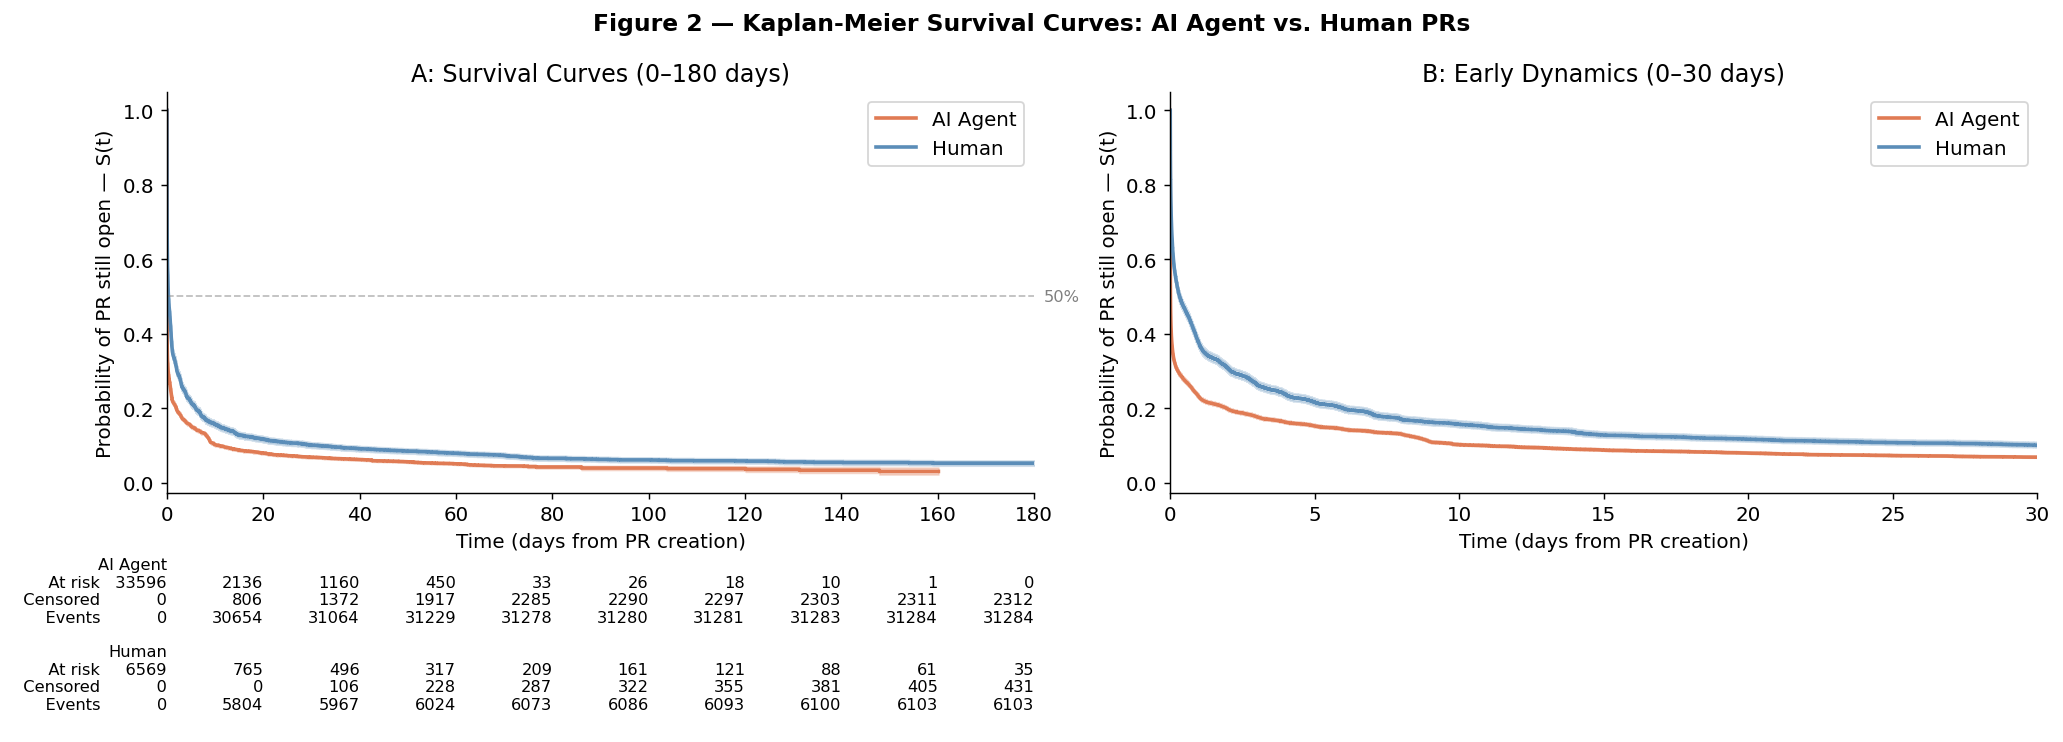

✓ Figure 2 saved


In [10]:
# ── Fig 2: Kaplan-Meier curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 2 — Kaplan-Meier Survival Curves: AI Agent vs. Human PRs",
             fontsize=13, fontweight="bold")

# Panel A: Full timeline (capped at 180 days)
ax = axes[0]
kmf_ai.plot_survival_function(
    ax=ax, ci_show=True, color=PALETTE["AI Agent"],
    linewidth=2, label="AI Agent"
)
kmf_hum.plot_survival_function(
    ax=ax, ci_show=True, color=PALETTE["Human"],
    linewidth=2, label="Human"
)
ax.set_xlim(0, 180)
ax.set_xlabel("Time (days from PR creation)")
ax.set_ylabel("Probability of PR still open — S(t)")
ax.set_title("A: Survival Curves (0–180 days)")
ax.axhline(0.5, ls="--", color="grey", alpha=0.5, linewidth=1)
ax.text(182, 0.5, "50%", va="center", color="grey", fontsize=9)

# Add at-risk counts
add_at_risk_counts(kmf_ai, kmf_hum, ax=ax, fontsize=9)

# Panel B: Early dynamics (first 30 days)
ax2 = axes[1]
kmf_ai.plot_survival_function(
    ax=ax2, ci_show=True, color=PALETTE["AI Agent"],
    linewidth=2, label="AI Agent"
)
kmf_hum.plot_survival_function(
    ax=ax2, ci_show=True, color=PALETTE["Human"],
    linewidth=2, label="Human"
)
ax2.set_xlim(0, 30)
ax2.set_xlabel("Time (days from PR creation)")
ax2.set_ylabel("Probability of PR still open — S(t)")
ax2.set_title("B: Early Dynamics (0–30 days)")

plt.tight_layout()
plt.savefig("fig2_kaplan_meier.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 2 saved")

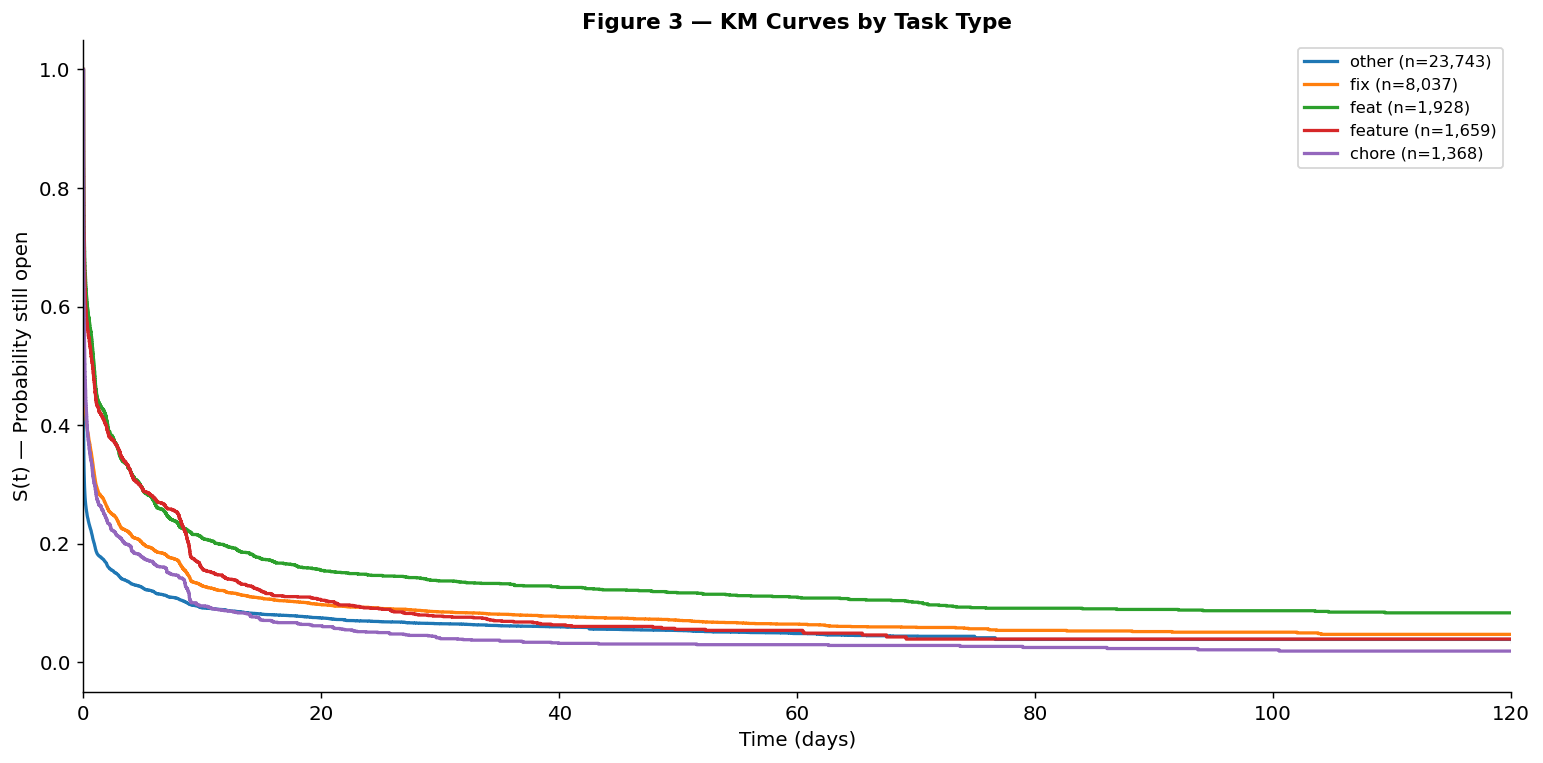

✓ Figure 3 saved


In [11]:
# ── Fig 3: KM by Task Type
fig, ax = plt.subplots(figsize=(12, 6))
task_types = df["task_type"].value_counts().head(5).index.tolist()
colors_t   = sns.color_palette("tab10", len(task_types))

for task, col in zip(task_types, colors_t):
    sub = df[df.task_type == task]
    if len(sub) > 50:
        kmf = KaplanMeierFitter(label=f"{task} (n={len(sub):,})")
        kmf.fit(sub["duration_days"], sub["event_observed"])
        kmf.plot_survival_function(ax=ax, ci_show=False,
                                   color=col, linewidth=1.8)

ax.set_xlim(0, 120)
ax.set_xlabel("Time (days)")
ax.set_ylabel("S(t) — Probability still open")
ax.set_title("Figure 3 — KM Curves by Task Type", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("fig3_km_task_type.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 3 saved")

---
## Block 6 — Log-Rank Test

### What is the Log-Rank Test?
The **log-rank test** (Mantel-Cox test) tests whether two or more survival functions are **statistically identical** across all time points. It is the standard non-parametric test for comparing KM curves.

**Hypotheses:**
- $H_0$: $S_{\text{AI}}(t) = S_{\text{Human}}(t)$ for all $t$ — the survival functions are identical.
- $H_1$: $S_{\text{AI}}(t) \neq S_{\text{Human}}(t)$ for some $t$.

The test statistic is chi-square distributed under $H_0$.  
**Limitation:** The log-rank test gives equal weight to all time points. If the hazard ratio changes over time (non-proportional hazards), it may have reduced power.

In [12]:
print("━" * 65)
print("BLOCK 6 ▸ Log-Rank Test: AI vs. Human")
print("━" * 65)

result = logrank_test(
    durations_A=df_ai["duration_days"],
    durations_B=df_hum["duration_days"],
    event_observed_A=df_ai["event_observed"],
    event_observed_B=df_hum["event_observed"],
)

print(f"\n  Test statistic (χ²) : {result.test_statistic:.4f}")
print(f"  Degrees of freedom  : 1")
print(f"  p-value             : {result.p_value:.6f}")

alpha = 0.05
if result.p_value < alpha:
    print(f"\n  ✓ SIGNIFICANT at α={alpha}: Reject H₀")
    print("    → The survival distributions of AI and human PRs differ significantly.")
else:
    print(f"\n  ✗ NOT SIGNIFICANT at α={alpha}: Fail to reject H₀")
    print("    → No statistically significant difference detected between groups.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 6 ▸ Log-Rank Test: AI vs. Human
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Test statistic (χ²) : 912.6783
  Degrees of freedom  : 1
  p-value             : 0.000000

  ✓ SIGNIFICANT at α=0.05: Reject H₀
    → The survival distributions of AI and human PRs differ significantly.


In [13]:
# ── Multivariate log-rank test by task type
print("━" * 65)
print("BLOCK 6b ▸ Multivariate Log-Rank Test by Task Type")
print("━" * 65)

result_task = multivariate_logrank_test(
    event_durations=df["duration_days"],
    groups=df["task_type"],
    event_observed=df["event_observed"],
)

print(f"\n  Test statistic (χ²) : {result_task.test_statistic:.4f}")
print(f"  p-value             : {result_task.p_value:.6f}")
if result_task.p_value < 0.05:
    print("  ✓ Survival distributions differ significantly across task types.")
else:
    print("  ✗ No significant difference across task types.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 6b ▸ Multivariate Log-Rank Test by Task Type
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Test statistic (χ²) : 1956.1804
  p-value             : 0.000000
  ✓ Survival distributions differ significantly across task types.


---
## Block 7 — Cox Proportional Hazards Model

### Model Rationale
While KM and log-rank test compare groups without adjustment, the **Cox Proportional Hazards (CPH) model** allows us to:
1. Control for confounding covariates simultaneously.
2. Estimate the effect size of each covariate via **Hazard Ratios (HR)**.
3. Handle both continuous and categorical covariates.

### Cox Model Formula
$$h(t|X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p)$$

- $h_0(t)$ = baseline hazard (left unspecified — semi-parametric).
- $\exp(\beta_j)$ = **Hazard Ratio** for covariate $X_j$.
- **HR > 1** → faster resolution (higher hazard = event happens sooner).
- **HR < 1** → slower resolution (lower hazard = event takes longer).

### Key Assumption
**Proportional Hazards:** The ratio of hazards between two individuals is constant over time. I verify this via:
- Schoenfeld residual tests (statistical).
- Log-log survival plots (graphical).

### Covariates Included
| Covariate | Interpretation |
|-----------|----------------|
| `is_agentic` | Primary: AI (1) vs. Human (0) |
| `log_churn` | Code volume — larger PRs may take longer |
| `log_files` | Number of files touched |
| `log_stars` | Repo popularity — busier repos may have faster reviews |
| `log_body_length` | PR description length — more context → faster review? |
| `is_silent` | PR with no description — harder to review |
| `log_reviews` | Reviewer engagement |
| `cdi` | Comment Diversity Index — broad reviewer base |

In [14]:
print("━" * 65)
print("BLOCK 7 ▸ Cox Proportional Hazards Model")
print("━" * 65)

# Select covariates for Cox model
BASE_COVARIATES = [
    "is_agentic",
    "log_churn",
    "log_files",
    "log_stars",
    "log_body_length",
    "is_silent",
    "log_reviews",
    "cdi",
]

# Add task and language dummies (these are boolean/numeric)
task_dummies = [c for c in df.columns if c.startswith("task_") and c != "task_other" and c != "task_type"]
lang_dummies = [c for c in df.columns if c.startswith("lang_")]

all_covariates = BASE_COVARIATES + task_dummies + lang_dummies
available_covs = [c for c in all_covariates if c in df.columns]

# Prepare Cox dataset - I ensure only numeric columns are used for fitting
cox_df = df[["duration_days", "event_observed"] + available_covs].copy()
cox_df = cox_df.dropna()

# Remove zero-variance columns (only check numeric ones to avoid the TypeError)
zero_var = [c for c in available_covs if cox_df[c].dtype != "object" and cox_df[c].std() == 0]
if zero_var:
    print(f"  Dropping zero-variance: {zero_var}")
    available_covs = [c for c in available_covs if c not in zero_var]

cox_df = cox_df[["duration_days", "event_observed"] + available_covs]
print(f"  Cox dataset: {len(cox_df):,} rows × {len(available_covs)} covariates")

# Fit Cox model
cph = CoxPHFitter(penalizer=0.01)  # small ridge penalty for stability
cph.fit(
    cox_df,
    duration_col="duration_days",
    event_col="event_observed",
    show_progress=True,
)

print("\n✓ Cox model fitted successfully")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 7 ▸ Cox Proportional Hazards Model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cox dataset: 40,165 rows × 27 covariates
Iteration 1: norm_delta = 6.85e-01, step_size = 0.9500, log_lik = -365303.17473, newton_decrement = 6.61e+03, seconds_since_start = 3.1
Iteration 2: norm_delta = 9.13e-02, step_size = 0.9500, log_lik = -359055.88449, newton_decrement = 1.72e+02, seconds_since_start = 5.1
Iteration 3: norm_delta = 7.10e-03, step_size = 0.9500, log_lik = -358882.32537, newton_decrement = 9.39e-01, seconds_since_start = 6.4
Iteration 4: norm_delta = 3.16e-05, step_size = 1.0000, log_lik = -358881.38379, newton_decrement = 2.32e-05, seconds_since_start = 7.4
Iteration 5: norm_delta = 1.91e-09, step_size = 1.0000, log_lik = -358881.38377, newton_decrement = 7.27e-14, seconds_since_start = 8.5
Convergence success after 5 iterations.

✓ Cox model fitted successfully


In [15]:
# Full Cox summary
print("━" * 65)
print("BLOCK 7 ▸ Cox Model Summary (Hazard Ratios)")
print("━" * 65)

cph.print_summary(decimals=4, model="Cox PH")

# Concordance index
c_idx = cph.concordance_index_
print(f"\n  Concordance Index (C-index): {c_idx:.4f}")
print("  (C-index = 0.5 → random; C-index = 1.0 → perfect discrimination)")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 7 ▸ Cox Model Summary (Hazard Ratios)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


model,lifelines.CoxPHFitter
duration col,'duration_days'
event col,'event_observed'
penalizer,0.01
l1 ratio,0.0
baseline estimation,breslow
number of observations,40165
number of events observed,37387
partial log-likelihood,-358881.3838
time fit was run,2026-04-12 13:57:37 UTC
model,Cox PH



  Concordance Index (C-index): 0.7204
  (C-index = 0.5 → random; C-index = 1.0 → perfect discrimination)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 7 ▸ Forest Plot of Hazard Ratios
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


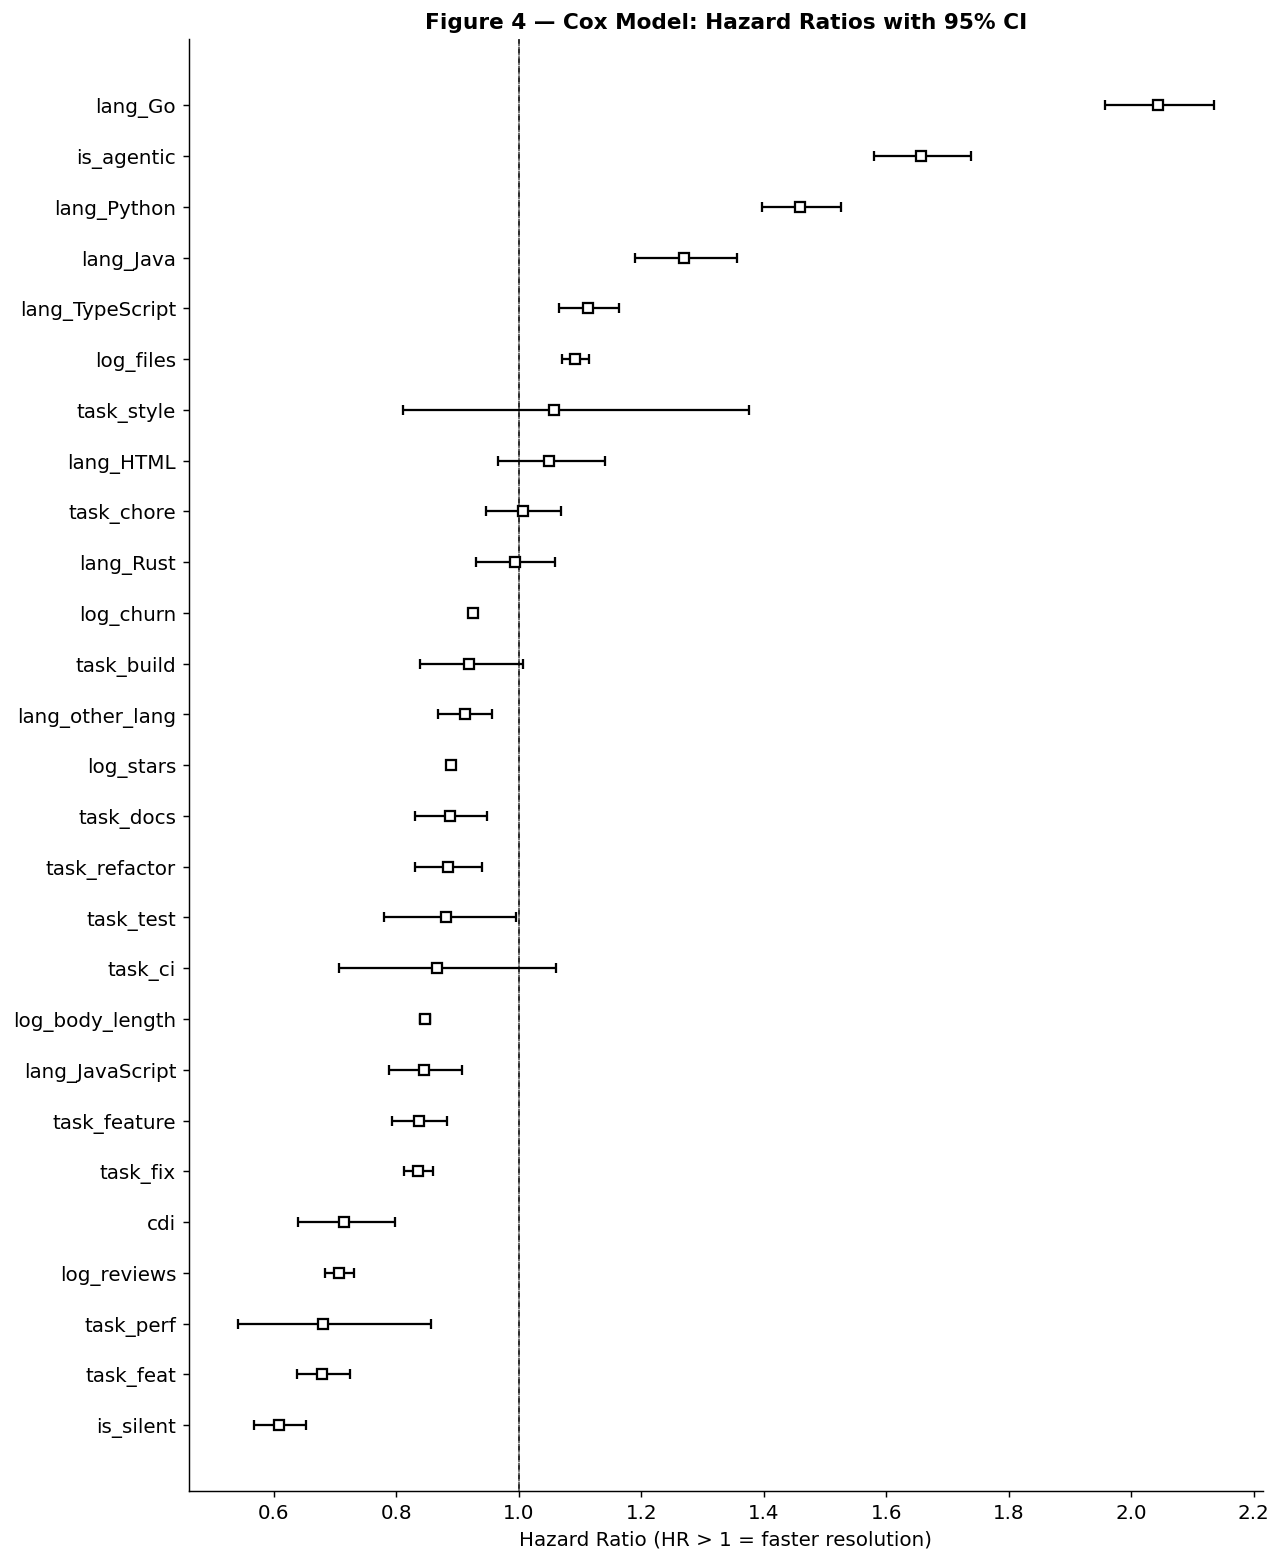

✓ Figure 4 saved


In [16]:
# ── Fig 4: Cox Forest Plot (Hazard Ratio Plot)
print("━" * 65)
print("BLOCK 7 ▸ Forest Plot of Hazard Ratios")
print("━" * 65)

fig, ax = plt.subplots(figsize=(10, max(6, len(available_covs) * 0.45)))

cph.plot(
    ax=ax,
    hazard_ratios=True
)

ax.axvline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Hazard Ratio (HR > 1 = faster resolution)")
ax.set_title("Figure 4 — Cox Model: Hazard Ratios with 95% CI",
             fontsize=12, fontweight="bold")

# Highlight is_agentic
plt.tight_layout()
plt.savefig("fig4_cox_forest_plot.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 4 saved")

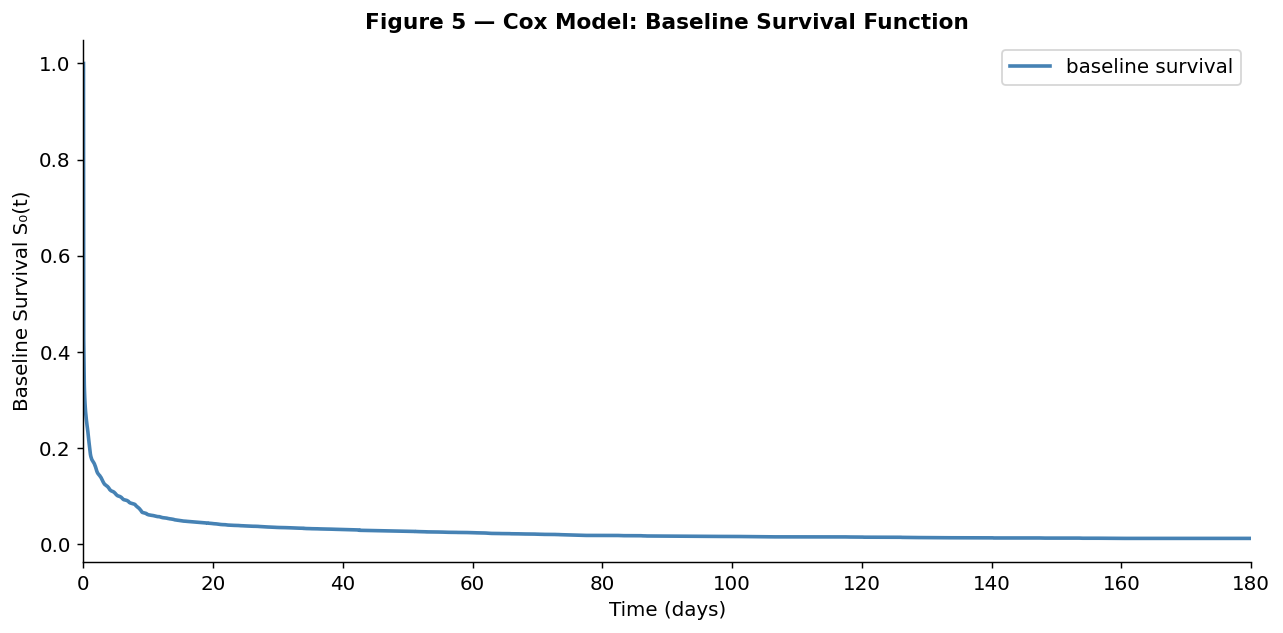

✓ Figure 5 saved


In [17]:
# ── Fig 5: Baseline survival function from Cox model
fig, ax = plt.subplots(figsize=(10, 5))

cph.baseline_survival_.plot(ax=ax, color="steelblue", linewidth=2)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Baseline Survival S₀(t)")
ax.set_title("Figure 5 — Cox Model: Baseline Survival Function",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 180)
plt.tight_layout()
plt.savefig("fig5_cox_baseline_survival.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 5 saved")

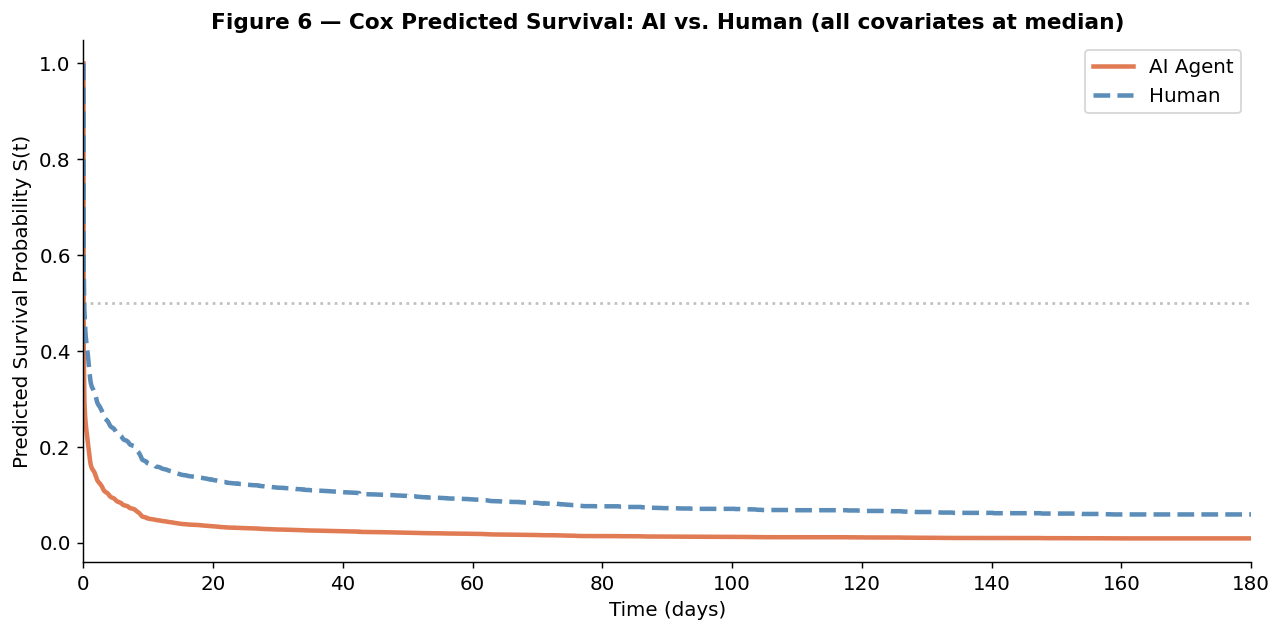

✓ Figure 6 saved


In [18]:
# ── Predicted survival: AI vs Human (all else at median)
fig, ax = plt.subplots(figsize=(10, 5))

# Build representative profiles
median_vals = {c: cox_df[c].median() for c in available_covs}

profile_ai  = pd.DataFrame({**median_vals, "is_agentic": [1]}, index=["AI Agent"])
profile_hum = pd.DataFrame({**median_vals, "is_agentic": [0]}, index=["Human"])

surv_ai  = cph.predict_survival_function(profile_ai)
surv_hum = cph.predict_survival_function(profile_hum)

ax.plot(surv_ai.index,  surv_ai.iloc[:, 0],  label="AI Agent",
        color=PALETTE["AI Agent"], linewidth=2.5)
ax.plot(surv_hum.index, surv_hum.iloc[:, 0], label="Human",
        color=PALETTE["Human"],    linewidth=2.5, linestyle="--")

ax.set_xlim(0, 180)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Predicted Survival Probability S(t)")
ax.set_title("Figure 6 — Cox Predicted Survival: AI vs. Human (all covariates at median)",
             fontsize=12, fontweight="bold")
ax.axhline(0.5, ls=":", color="grey", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig("fig6_cox_predicted_survival.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 6 saved")

---
## Block 8 — Proportional Hazards Assumption Diagnostics

The **Proportional Hazards (PH) assumption** requires that the hazard ratio between any two subjects is constant over time. Violations indicate that the effect of a covariate changes at different stages of the PR lifecycle.

### Diagnostic Methods
1. **Schoenfeld Residuals Test** — formal statistical test. A significant p-value indicates a time-varying effect (PH violated).
2. **Log-Log Plot** — graphical check. If the lines are parallel on the log(-log(S(t))) vs. log(t) scale, PH holds for that covariate.

In [19]:
print("━" * 65)
print("BLOCK 8 ▸ PH Assumption: Schoenfeld Residuals Test")
print("━" * 65)

# lifelines built-in PH test
try:
    ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05,
                                     show_plots=False, quiet=False)
except Exception as e:
    print(f"  Note: {e}")
    print("  → Run cph.check_assumptions() in interactive environment for full diagnostics.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 8 ▸ PH Assumption: Schoenfeld Residuals Test
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Note: ProportionalHazardMixin.check_assumptions() got an unexpected keyword argument 'quiet'
  → Run cph.check_assumptions() in interactive environment for full diagnostics.


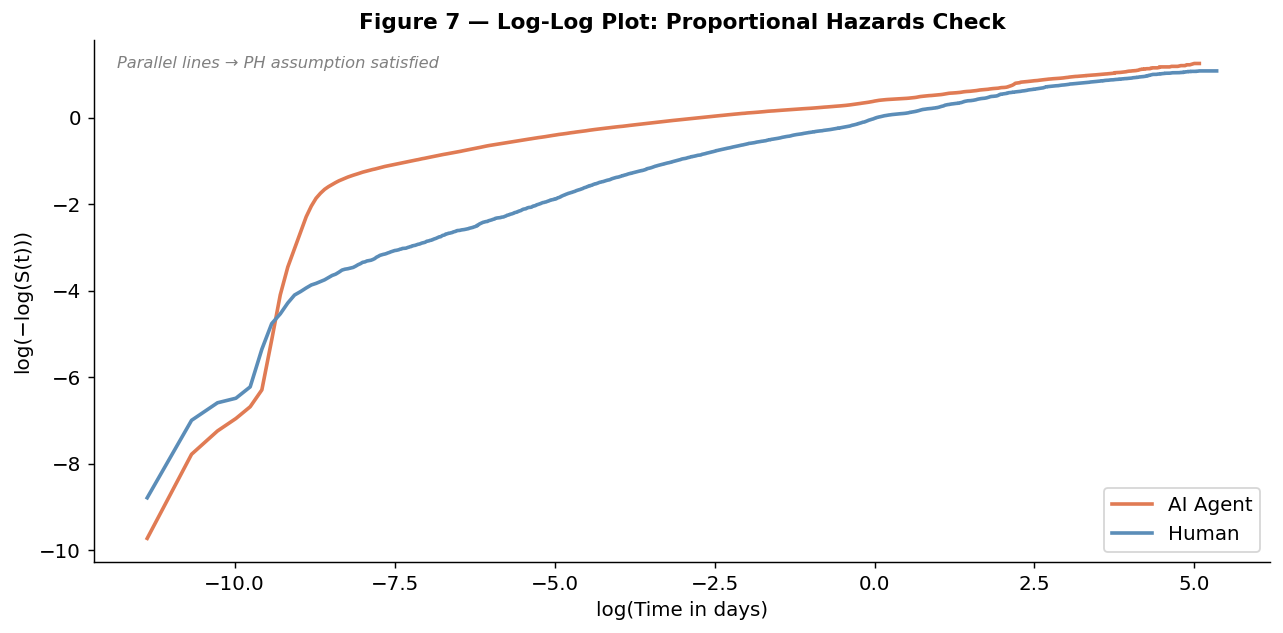

✓ Figure 7 saved


In [20]:
# ── Fig 7: Log-Log Plot (graphical PH check)
fig, ax = plt.subplots(figsize=(10, 5))

for group, label in [(1, "AI Agent"), (0, "Human")]:
    sub = df[df.is_agentic == group]
    kmf = KaplanMeierFitter()
    kmf.fit(sub["duration_days"], sub["event_observed"])

    sf  = kmf.survival_function_["KM_estimate"]
    t   = sf.index
    s   = sf.values

    # Avoid log(0)
    mask = (s > 0) & (s < 1) & (t > 0)
    log_log_s = np.log(-np.log(s[mask]))
    log_t     = np.log(t[mask])

    ax.plot(log_t, log_log_s, label=label,
            color=PALETTE[label], linewidth=2)

ax.set_xlabel("log(Time in days)")
ax.set_ylabel("log(−log(S(t)))")
ax.set_title("Figure 7 — Log-Log Plot: Proportional Hazards Check",
             fontsize=12, fontweight="bold")
ax.legend()
ax.text(0.02, 0.97, "Parallel lines → PH assumption satisfied",
        transform=ax.transAxes, va="top", fontsize=9,
        color="grey", style="italic")
plt.tight_layout()
plt.savefig("fig7_log_log_plot.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 7 saved")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 8b ▸ Schoenfeld Residuals for 'is_agentic'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


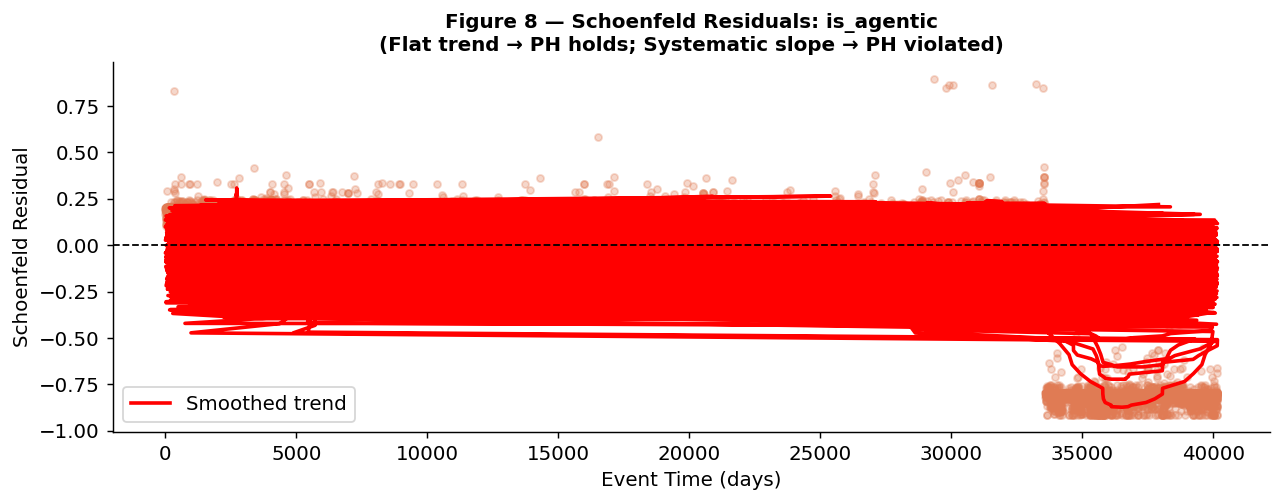

✓ Figure 8 saved


In [21]:
# ── Fig 8: Schoenfeld Residuals Plot for is_agentic
print("━" * 65)
print("BLOCK 8b ▸ Schoenfeld Residuals for 'is_agentic'")
print("━" * 65)

fig, ax = plt.subplots(figsize=(10, 4))

try:
    schoenfeld = cph.compute_residuals(cox_df, kind="schoenfeld")
    if "is_agentic" in schoenfeld.columns:
        ax.scatter(schoenfeld.index, schoenfeld["is_agentic"],
                   alpha=0.3, s=15, color=PALETTE["AI Agent"])
        # Smoothed trend
        from scipy.signal import savgol_filter
        if len(schoenfeld) > 50:
            smoothed = savgol_filter(schoenfeld["is_agentic"].values, 51, 3)
            ax.plot(schoenfeld.index, smoothed,
                    color="red", linewidth=2, label="Smoothed trend")
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        ax.set_xlabel("Event Time (days)")
        ax.set_ylabel("Schoenfeld Residual")
        ax.set_title("Figure 8 — Schoenfeld Residuals: is_agentic\n"
                     "(Flat trend → PH holds; Systematic slope → PH violated)",
                     fontsize=11, fontweight="bold")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "is_agentic residuals not available",
                ha="center", transform=ax.transAxes)
except Exception as e:
    ax.text(0.5, 0.5, f"Schoenfeld residuals: {e}",
            ha="center", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.savefig("fig8_schoenfeld_residuals.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 8 saved")

---
## Block 9 — Time-Stratified Cox Model (Robustness Check)

If the PH assumption is violated for any covariate, I can **stratify** the Cox model by that variable. Stratification allows a separate baseline hazard per stratum while sharing the other $\beta$ coefficients.

Here we fit a **stratified Cox model** using `is_agentic` as the stratification variable as a robustness check — this tests whether the *other* covariates have proportional effects within each author type group.

In [22]:
print("━" * 65)
print("BLOCK 9 ▸ Stratified Cox Model (Robustness Check)")
print("━" * 65)

# Covariates WITHOUT is_agentic (it becomes the strata)
strat_covs = [c for c in available_covs if c != "is_agentic"]

cox_df_strat = df[["duration_days", "event_observed", "is_agentic"] + strat_covs].copy().dropna()

cph_strat = CoxPHFitter(penalizer=0.01)
cph_strat.fit(
    cox_df_strat,
    duration_col="duration_days",
    event_col="event_observed",
    strata=["is_agentic"],
    show_progress=True,
)

print("\n✓ Stratified Cox model fitted")
cph_strat.print_summary(decimals=4)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 9 ▸ Stratified Cox Model (Robustness Check)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Iteration 1: norm_delta = 5.98e-01, step_size = 0.9500, log_lik = -348760.21318, newton_decrement = 5.43e+03, seconds_since_start = 1.1
Iteration 2: norm_delta = 8.23e-02, step_size = 0.9500, log_lik = -343404.45777, newton_decrement = 1.37e+02, seconds_since_start = 2.8
Iteration 3: norm_delta = 6.38e-03, step_size = 0.9500, log_lik = -343265.31483, newton_decrement = 1.02e+00, seconds_since_start = 5.7
Iteration 4: norm_delta = 5.35e-05, step_size = 1.0000, log_lik = -343264.29107, newton_decrement = 7.51e-05, seconds_since_start = 8.7
Iteration 5: norm_delta = 6.69e-09, step_size = 1.0000, log_lik = -343264.29100, newton_decrement = 8.67e-13, seconds_since_start = 9.9
Convergence success after 5 iterations.

✓ Stratified Cox model fitted


model,lifelines.CoxPHFitter
duration col,'duration_days'
event col,'event_observed'
penalizer,0.01
l1 ratio,0.0
strata,is_agentic
baseline estimation,breslow
number of observations,40165
number of events observed,37387
partial log-likelihood,-343264.2910
time fit was run,2026-04-12 13:58:15 UTC


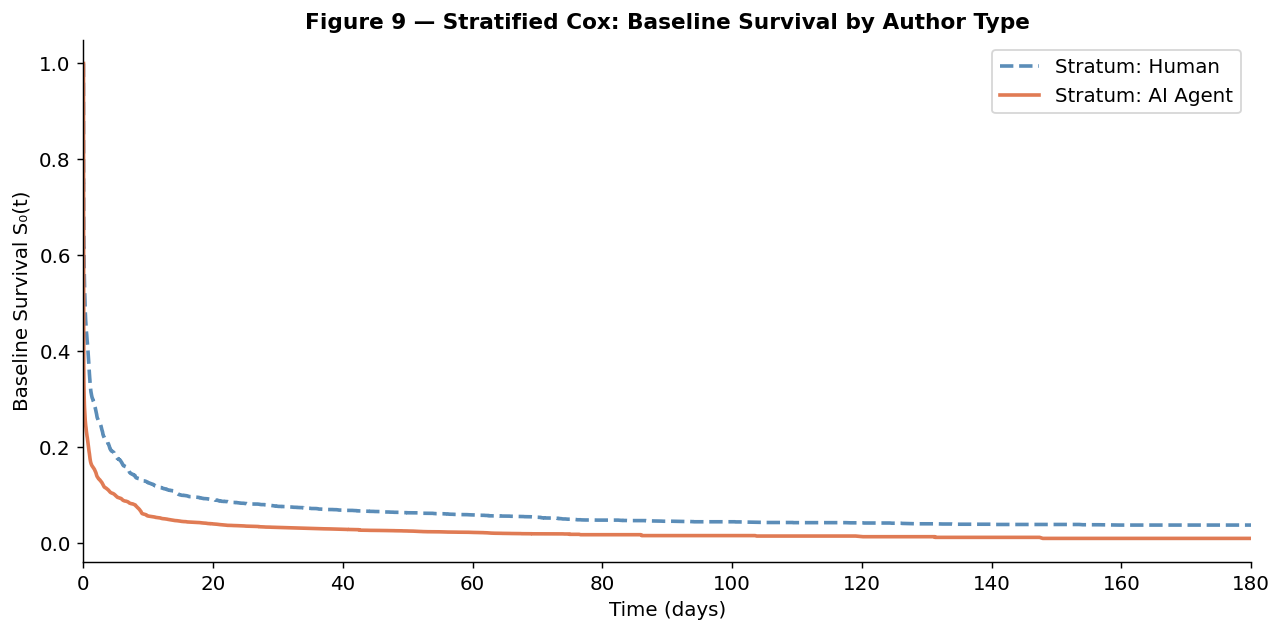

✓ Figure 9 saved


In [23]:
# ── Fig 9: Stratified Cox - Baseline survival by group
fig, ax = plt.subplots(figsize=(10, 5))

bs = cph_strat.baseline_survival_
for col in bs.columns:
    label = "AI Agent" if str(col) == "1" else "Human"
    color = PALETTE.get(label, "grey")
    bs[col].plot(ax=ax, label=f"Stratum: {label}",
                 color=color, linewidth=2,
                 linestyle="-" if label == "AI Agent" else "--")

ax.set_xlim(0, 180)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Baseline Survival S₀(t)")
ax.set_title("Figure 9 — Stratified Cox: Baseline Survival by Author Type",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig9_stratified_cox.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 9 saved")

---
## Block 10 — Merged-Only Survival Analysis

As a supplementary analysis, I focus exclusively on **merged PRs** and ask:  
*Among PRs that were eventually merged, do AI-authored PRs get merged faster?*

This eliminates closed-without-merge events and isolates the merge pathway.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 10 ▸ Merged-Only Survival Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Median time-to-merge (AI)    : 0.0 days
  Median time-to-merge (Human) : 0.6 days

  Log-rank χ² = 423.733, p = 0.000000


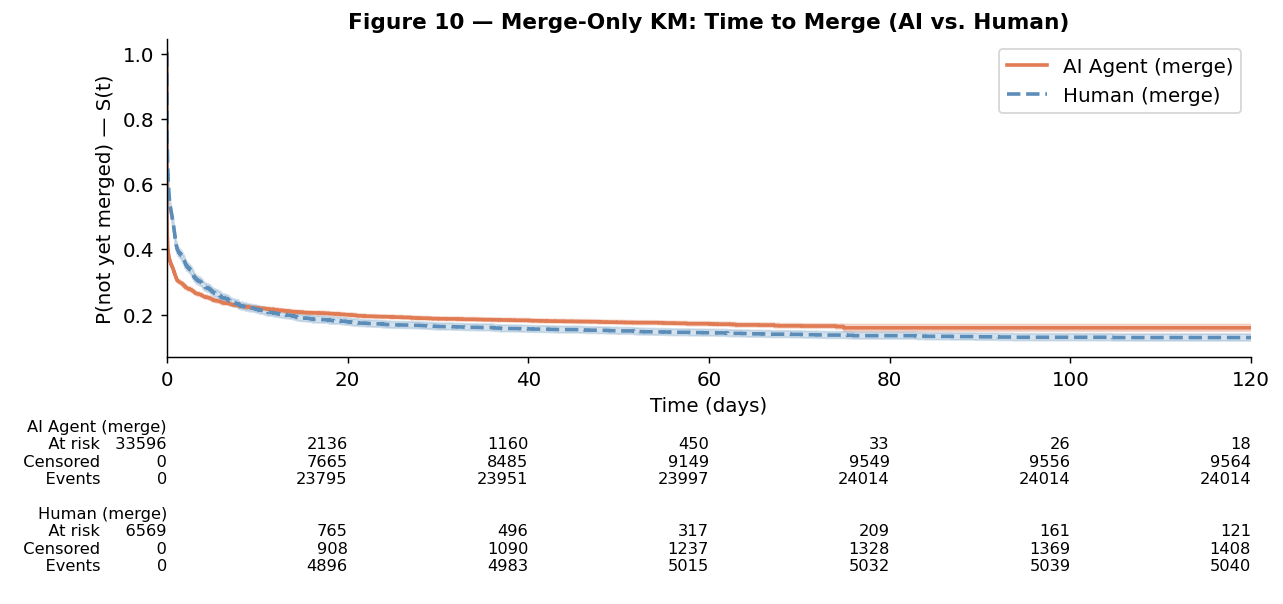

✓ Figure 10 saved


In [24]:
print("━" * 65)
print("BLOCK 10 ▸ Merged-Only Survival Analysis")
print("━" * 65)

# For this analysis:
# - event = merged (1 if merged, 0 if closed-without-merge or still open)
df_merged = df.copy()
df_merged["event_merge_only"] = df_merged["merged"].astype(int)

df_ai_m  = df_merged[df_merged.is_agentic == 1]
df_hum_m = df_merged[df_merged.is_agentic == 0]

kmf_ai_m  = KaplanMeierFitter(label="AI Agent (merge)")
kmf_hum_m = KaplanMeierFitter(label="Human (merge)")
kmf_ai_m.fit(df_ai_m["duration_days"],  df_ai_m["event_merge_only"])
kmf_hum_m.fit(df_hum_m["duration_days"], df_hum_m["event_merge_only"])

print(f"  Median time-to-merge (AI)    : {kmf_ai_m.median_survival_time_:.1f} days")
print(f"  Median time-to-merge (Human) : {kmf_hum_m.median_survival_time_:.1f} days")

# Log-rank test
lr_merge = logrank_test(
    df_ai_m["duration_days"],  df_hum_m["duration_days"],
    df_ai_m["event_merge_only"], df_hum_m["event_merge_only"]
)
print(f"\n  Log-rank χ² = {lr_merge.test_statistic:.3f}, p = {lr_merge.p_value:.6f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
kmf_ai_m.plot_survival_function(ax=ax, ci_show=True,
                                  color=PALETTE["AI Agent"], linewidth=2)
kmf_hum_m.plot_survival_function(ax=ax, ci_show=True,
                                   color=PALETTE["Human"], linewidth=2, linestyle="--")
ax.set_xlim(0, 120)
ax.set_xlabel("Time (days)")
ax.set_ylabel("P(not yet merged) — S(t)")
ax.set_title("Figure 10 — Merge-Only KM: Time to Merge (AI vs. Human)",
             fontsize=12, fontweight="bold")
add_at_risk_counts(kmf_ai_m, kmf_hum_m, ax=ax, fontsize=9)
plt.tight_layout()
plt.savefig("fig10_km_merge_only.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 10 saved")

---
## Block 11 — Comprehensive Results Summary

Extract and display all key findings in a structured format.

In [25]:
print("=" * 65)
print("  PART 3 — SURVIVAL ANALYSIS RESULTS SUMMARY")
print("=" * 65)

print("\n[1] KAPLAN-MEIER — Median Survival Time")
print(f"    AI Agent : {kmf_ai.median_survival_time_:.1f} days")
print(f"    Human    : {kmf_hum.median_survival_time_:.1f} days")
diff = kmf_hum.median_survival_time_ - kmf_ai.median_survival_time_
if diff > 0:
    print(f"    → AI PRs resolve {diff:.1f} days FASTER on median.")
elif diff < 0:
    print(f"    → Human PRs resolve {-diff:.1f} days FASTER on median.")
else:
    print(f"    → No difference in median survival times.")

print("\n[2] LOG-RANK TEST")
print(f"    χ² = {result.test_statistic:.4f}, p = {result.p_value:.6f}")
print(f"    → {'SIGNIFICANT' if result.p_value < 0.05 else 'NOT SIGNIFICANT'} difference between AI and human survival curves.")

print("\n[3] COX PROPORTIONAL HAZARDS — Key Coefficients")
summary = cph.summary
for var in ["is_agentic", "log_churn", "log_reviews", "log_stars", "is_silent", "cdi"]:
    if var in summary.index:
        hr   = np.exp(summary.loc[var, "coef"])
        p    = summary.loc[var, "p"]
        ci_l = np.exp(summary.loc[var, "coef lower 95%"])
        ci_u = np.exp(summary.loc[var, "coef upper 95%"])
        sig  = "*" * (int(p < 0.05) + int(p < 0.01) + int(p < 0.001))
        direction = "faster" if hr > 1 else "slower"
        print(f"    {var:<22s} HR={hr:.3f} [{ci_l:.3f}, {ci_u:.3f}]  p={p:.4f} {sig}  → {direction} resolution")

print(f"\n    Concordance Index: {cph.concordance_index_:.4f}")
print("    (* p<0.05, ** p<0.01, *** p<0.001)")

print("\n[4] MERGE-ONLY ANALYSIS")
print(f"    Median time-to-merge (AI)    : {kmf_ai_m.median_survival_time_:.1f} days")
print(f"    Median time-to-merge (Human) : {kmf_hum_m.median_survival_time_:.1f} days")
print(f"    Log-rank p = {lr_merge.p_value:.6f}")

  PART 3 — SURVIVAL ANALYSIS RESULTS SUMMARY

[1] KAPLAN-MEIER — Median Survival Time
    AI Agent : 0.0 days
    Human    : 0.3 days
    → AI PRs resolve 0.3 days FASTER on median.

[2] LOG-RANK TEST
    χ² = 912.6783, p = 0.000000
    → SIGNIFICANT difference between AI and human survival curves.

[3] COX PROPORTIONAL HAZARDS — Key Coefficients
    is_agentic             HR=1.657 [1.581, 1.738]  p=0.0000 ***  → faster resolution
    log_churn              HR=0.925 [0.919, 0.932]  p=0.0000 ***  → slower resolution
    log_reviews            HR=0.707 [0.684, 0.730]  p=0.0000 ***  → slower resolution
    log_stars              HR=0.889 [0.883, 0.895]  p=0.0000 ***  → slower resolution
    is_silent              HR=0.608 [0.567, 0.652]  p=0.0000 ***  → slower resolution
    cdi                    HR=0.714 [0.640, 0.798]  p=0.0000 ***  → slower resolution

    Concordance Index: 0.7204
    (* p<0.05, ** p<0.01, *** p<0.001)

[4] MERGE-ONLY ANALYSIS
    Median time-to-merge (AI)    : 0.0 d

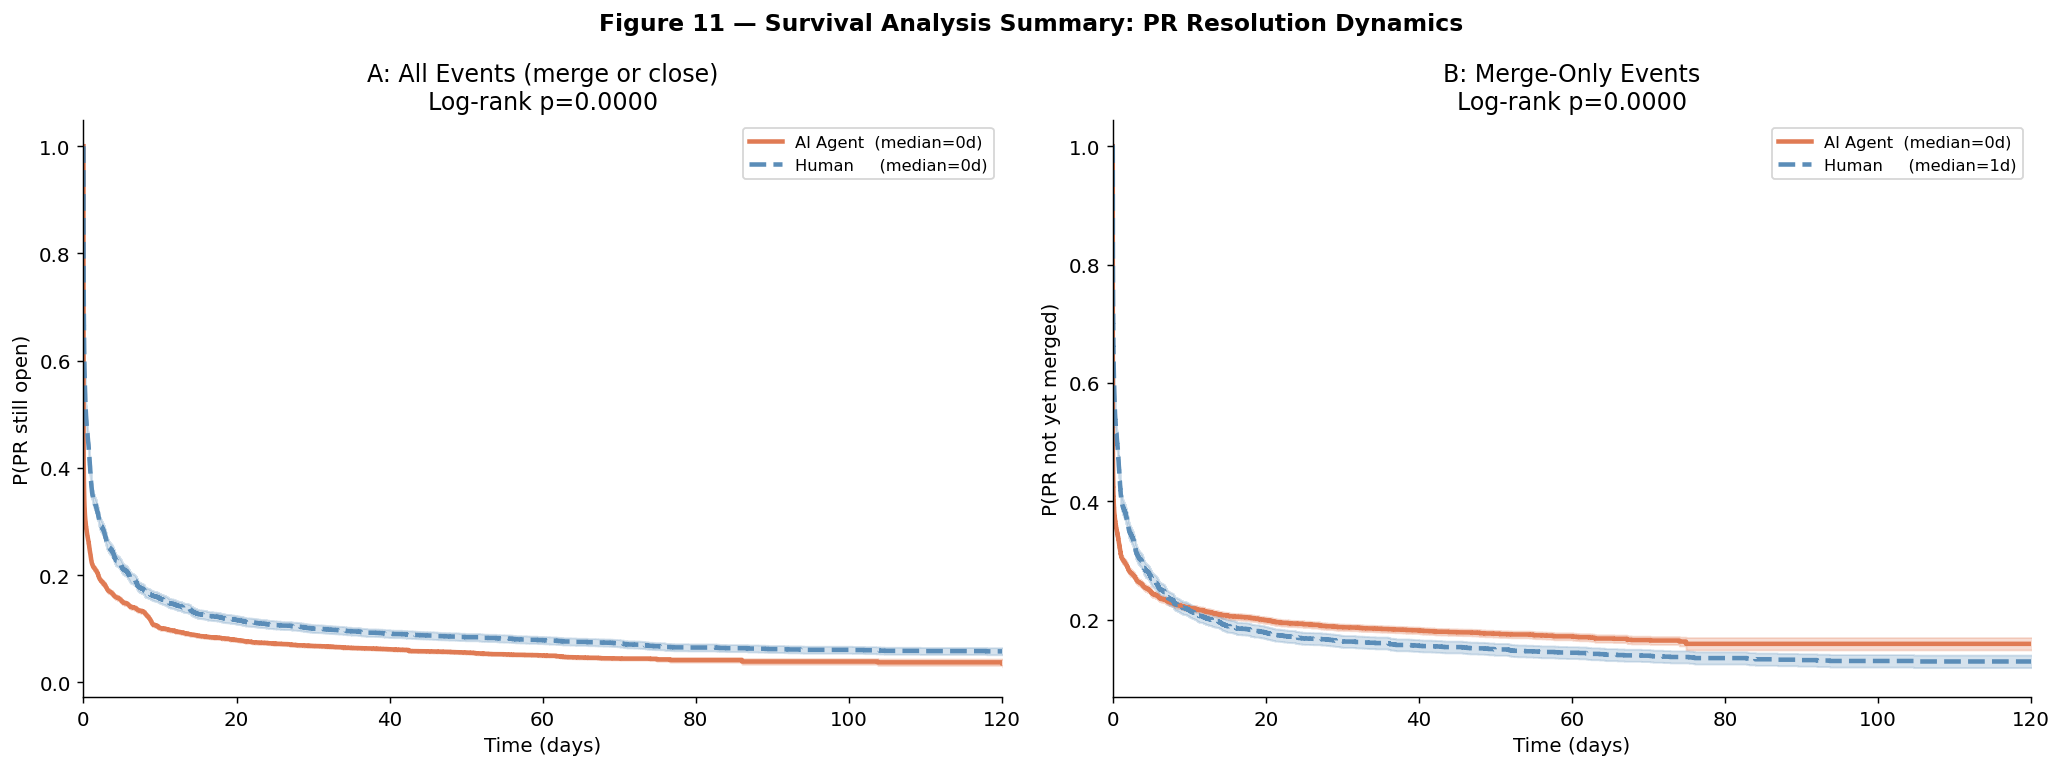

✓ Figure 11 saved — All analysis complete!

  PART 3 COMPLETE — Survival Analysis of PR Lifecycle


In [26]:
# ── Final Summary Figure: All KM curves side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 11 — Survival Analysis Summary: PR Resolution Dynamics",
             fontsize=13, fontweight="bold")

# Panel A: All events (merge OR close)
ax = axes[0]
kmf_ai.plot_survival_function(
    ax=ax, ci_show=True, color=PALETTE["AI Agent"],
    linewidth=2.5, label=f"AI Agent  (median={kmf_ai.median_survival_time_:.0f}d)"
)
kmf_hum.plot_survival_function(
    ax=ax, ci_show=True, color=PALETTE["Human"],
    linewidth=2.5, linestyle="--",
    label=f"Human     (median={kmf_hum.median_survival_time_:.0f}d)"
)
ax.set_xlim(0, 120)
ax.set_xlabel("Time (days)")
ax.set_ylabel("P(PR still open)")
ax.set_title(f"A: All Events (merge or close)\nLog-rank p={result.p_value:.4f}")
ax.legend(fontsize=9)

# Panel B: Merge-only events
ax2 = axes[1]
kmf_ai_m.plot_survival_function(
    ax=ax2, ci_show=True, color=PALETTE["AI Agent"],
    linewidth=2.5, label=f"AI Agent  (median={kmf_ai_m.median_survival_time_:.0f}d)"
)
kmf_hum_m.plot_survival_function(
    ax=ax2, ci_show=True, color=PALETTE["Human"],
    linewidth=2.5, linestyle="--",
    label=f"Human     (median={kmf_hum_m.median_survival_time_:.0f}d)"
)
ax2.set_xlim(0, 120)
ax2.set_xlabel("Time (days)")
ax2.set_ylabel("P(PR not yet merged)")
ax2.set_title(f"B: Merge-Only Events\nLog-rank p={lr_merge.p_value:.4f}")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig11_summary_km.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figure 11 saved — All analysis complete!")

print("\n" + "=" * 65)
print("  PART 3 COMPLETE — Survival Analysis of PR Lifecycle")
print("=" * 65)